In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates

# Load the iris dataset
iris = load_iris()

In [5]:
# Konversi dataset iris menjadi DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df ["Species"] = iris.target_names[iris.target]

# Defenisikan X (Fitur) dan y (target/label)
X = df.drop(columns=["Species"])
y = df["Species"]

print(X)



     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [6]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

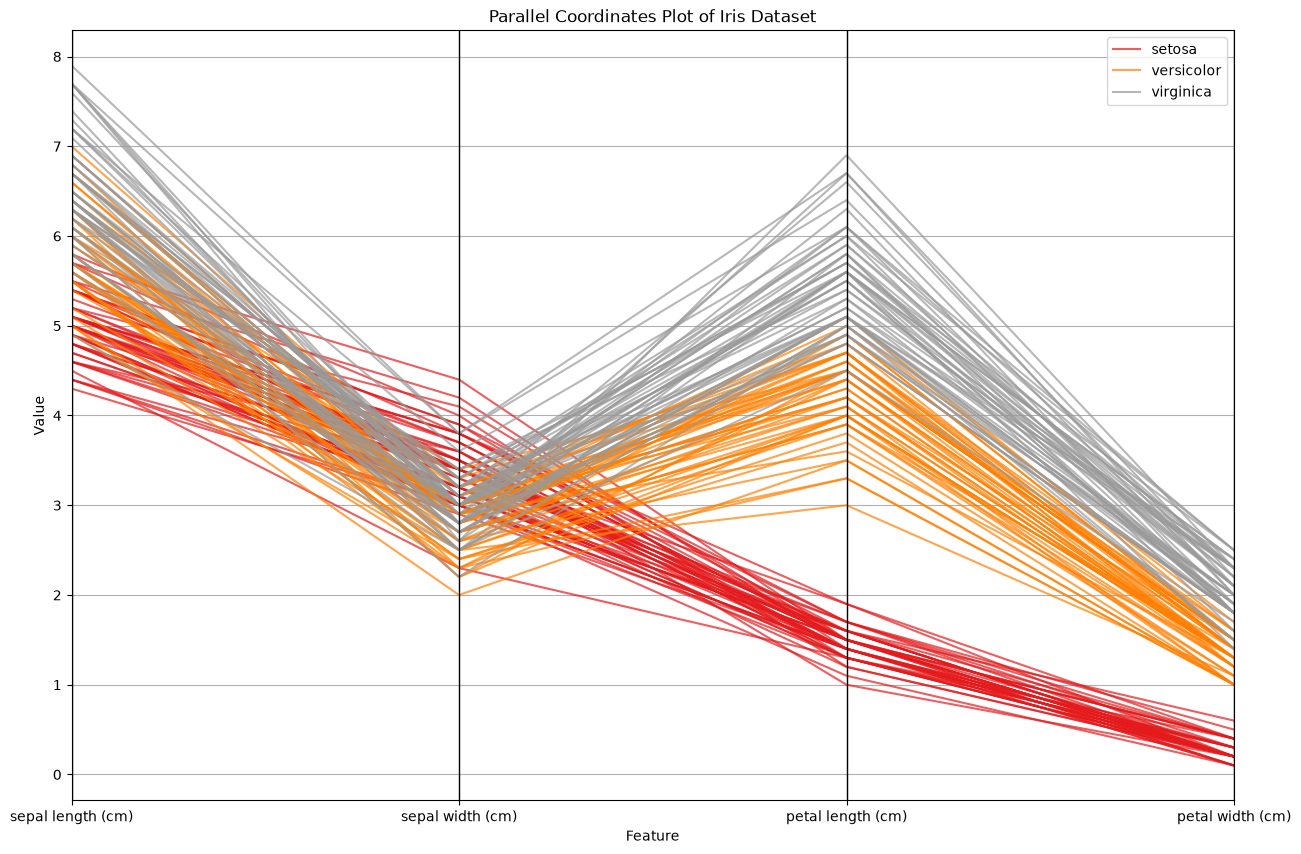

In [7]:
# Plot Parallel Coordinates
plt.figure(figsize=(15, 10))
parallel_coordinates(df, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot of Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()


In [9]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
y = lab.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X,  test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# k = 3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [12]:
y_pred = knn.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [13]:
result = accuracy_score(y_test, y_pred)
result

0.9666666666666667

In [14]:
df = pd.read_csv('athletes.csv')
print(df)


    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


In [15]:
feature_columns = ['speed', 'agility']
X = df[feature_columns].values
y = df['draft'].values

In [16]:
X

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

In [17]:
y

<StringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

In [18]:
#encode data y menjadi numerik
en = LabelEncoder()
y = en.fit_transform(y)
y


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


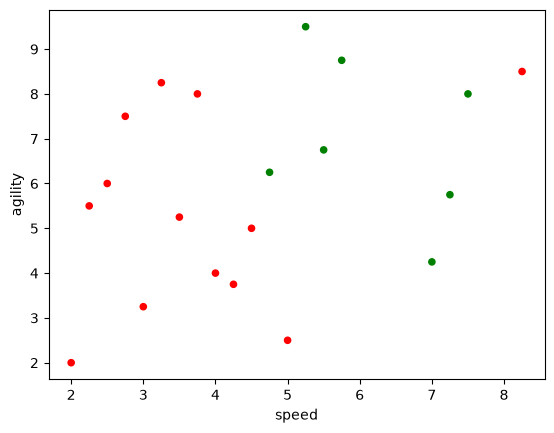

In [19]:
from numpy import where
df['key1'] = (y)
colors = np.where(df["key1"]==0,'r','g')
print(colors)
df.plot.scatter(x=1,y=2,c=colors)
plt.show()


In [20]:
# split train test
X_train, X_test = train_test_split(X, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=0)

In [21]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)


,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [22]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

In [23]:
result = accuracy_score(y_test, y_pred)
result


0.75

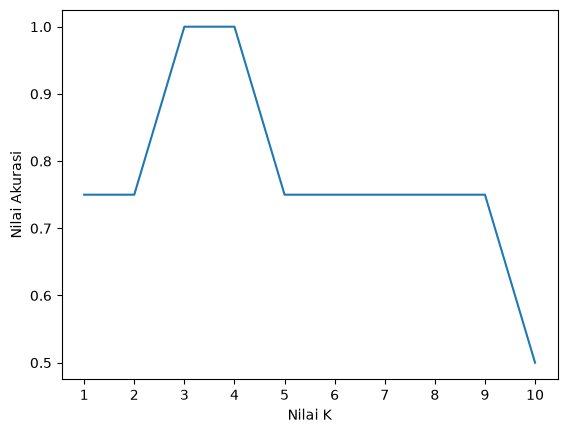

In [24]:
#untuk menemukan nilai K yang tepat, bisa dengan mencoba beberapa variasi nilai K dan melih
array_k = []
for i in range(1,11):
 knn = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
 knn.fit(X_train, y_train)
 y_pred = knn.predict(X_test)
 # Calculate accuracy
 result = accuracy_score(y_test, y_pred)
 # Store the accuracy result
 array_k.append(result)
plt.plot(array_k)
plt.ylabel('Nilai Akurasi')
plt.xlabel('Nilai K')
plt.xticks(np.arange(10),('1','2','3','4','5','6','7','8','9','10'))
plt.show()

### TUGAS 

In [ ]:
# Prediksi draft untuk atlet 
new_athletes = [[7.5, 7.0], [4.0, 6.5]]

pred_encoded = knn.predict(new_athletes)
pred_label = en.inverse_transform(pred_encoded)

for data, label in zip(new_athletes, pred_label):
    print(f"Input {data} -> Prediksi draft: {label}")

Input [7.5, 7.0] -> Prediksi draft: no
Input [4.0, 6.5] -> Prediksi draft: no


### Penjelasan :

 Cara kerja nya 
knn.predict() mencari 5 atlet yang paling mirip sama data baru (atau paling deket jaraknya kalau digambar di grafik) dari situ kita lihat  kebanyakan dari 5 tetangga itu draft-nya yes atau no? jadi yang paling banyak adalah jawaban nya

In [28]:
distances, indices = knn.kneighbors([[7.5, 7.0]])
print(df.iloc[indices[0]][['speed', 'agility', 'draft']])

    speed  agility draft
15   5.50     6.75   yes
14   4.75     6.25   yes
3    3.25     8.25    no
1    3.75     8.00    no
7    3.00     3.25    no
10   2.00     2.00    no
6    3.50     5.25    no
2    2.25     5.50    no
12   8.25     8.50    no
8    4.00     4.00    no


Berdasarkan model KNN k=5 yang dilatih dari data training, kedua atlet input ([7.5, 7.0] dan [4.0, 6.5]) diprediksi tidak masuk draft no. Untuk input [7.5, 7.0], hal ini terjadi karena 3 dari 5 tetangga terdekatnya di data training berlabel no, termasuk satu titik dengan speed dan agility tertinggi (8.25, 8.50) yang juga no. Hasil ini menunjukkan bahwa prediksi KNN sangat bergantung pada data mana saja yang termasuk dalam training set, karena beberapa titik yes yang secara visual lebih mirip dengan input ( speed 7.50 dan 7.25) masuk ke dalam data test, sehingga tidak ikut memengaruhi voting KNN.

In [30]:
# Tugas: Prediksi Species untuk data Iris baru

# Latih ulang model KNN khusus untuk dataset iris (agar tidak tertimpa oleh model atlet)
X_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y_iris = iris.target_names[iris.target]

lab_iris = LabelEncoder()
y_iris_encoded = lab_iris.fit_transform(y_iris)

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris_encoded, test_size=0.2, random_state=0
)

knn_iris = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_iris.fit(X_train_iris, y_train_iris)

# Data baru yang akan diprediksi
input_data = [
    [7.1, 1.2, 5.0, 2.0],
    [5.1, 3.5, 1.4, 0.2],
    [6.4, 3.7, 4.2, 2.2]
]
input_data_df = pd.DataFrame(input_data, columns=iris.feature_names)

pred_encoded = knn_iris.predict(input_data_df)
pred_species = lab_iris.inverse_transform(pred_encoded)

for data, species in zip(input_data, pred_species):
    print(f"Input {data} -> Prediksi Species: {species}")

Input [7.1, 1.2, 5.0, 2.0] -> Prediksi Species: virginica
Input [5.1, 3.5, 1.4, 0.2] -> Prediksi Species: setosa
Input [6.4, 3.7, 4.2, 2.2] -> Prediksi Species: versicolor


Kode di atas digunakan untuk menebak 3 data bunga baru masuk spesies iris yang mana (setosa, versicolor, atau virginica) data iris dibikin ulang jadi X_iris dan y_iris, soalnya variabel X dan y sebelumnya udah kepake buat data atlet, jadi kalau nggak dibikin ulang modelnya bisa salah nama spesies terus diubah jadi angka 0, 1, 2 pakai LabelEncoder, soalnya model cuma ngerti angka, bukan teks.lalu data dibagi menjadi data 80% dan data uji 20% lalu data baru yanng mau di prediksi diubah dulu jadi DataFrame biar formatnya sama jadi hasil nya berupa angka jadi diubah balik jadi nama spesies aslinya pakai inverse_transform, lalu hasilnya tampil pakai perulangan 